In [1]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
import warnings
warnings.filterwarnings("ignore")

In [2]:
# # # # # # # # # # # 
# tag = '2022041809_a04' 
# which_train = '01'
# which_test = '01' # 'train' '01' 
# test_ood = True
# samp_size = 500

# n_epochs = 30
# eval_bs = 6

# normed_latent = True
# use_cuda = True
# empty_cuda = True
# cuda_ids = [0,1,2,3]
# # # # # # # # # # # 

2022041807_a03_1000n_train
Loaded model weights results/models/2022041807_a03/29.pt
Let's use 4 GPUs!
Eval set anchors: data/model_ready/01/train/anchor_smiles.csv


  0%|          | 0/1000 [00:00<?, ?it/s]

Saved smiles and coords to results/umapped_dfs/2022041807_a03_1000n_train_32neigh_mindist0pt1.csv!


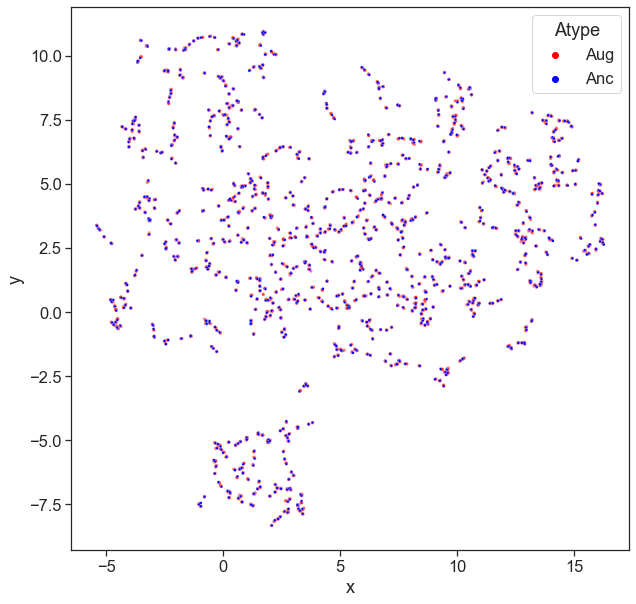

2022041807_a03_1000n_test
Loaded model weights results/models/2022041807_a03/29.pt
Let's use 4 GPUs!
Eval set anchors: data/model_ready/01/test/anchor_smiles.csv


  0%|          | 0/1000 [00:00<?, ?it/s]

Saved smiles and coords to results/umapped_dfs/2022041807_a03_1000n_test_32neigh_mindist0pt1.csv!


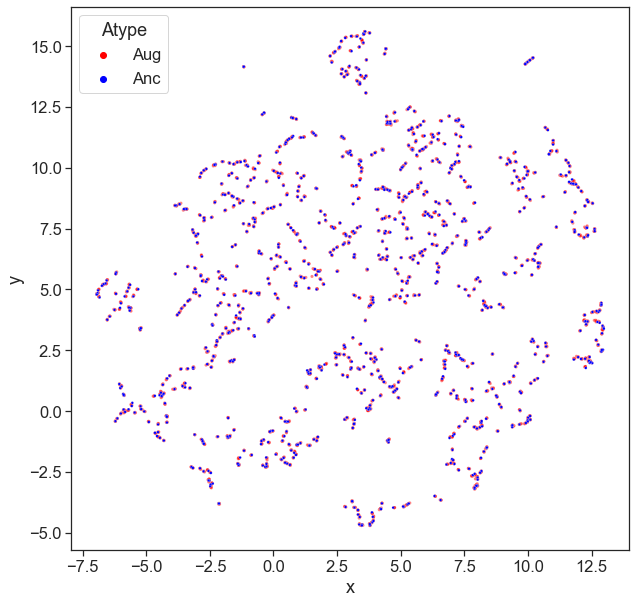

2022041807_a03_1000n_ood
Loaded model weights results/models/2022041807_a03/29.pt
Let's use 4 GPUs!
Eval set anchors: data/model_ready/01/test/anchor_smiles_ood.csv


  0%|          | 0/1000 [00:00<?, ?it/s]

Saved smiles and coords to results/umapped_dfs/2022041807_a03_1000n_ood_32neigh_mindist0pt1.csv!


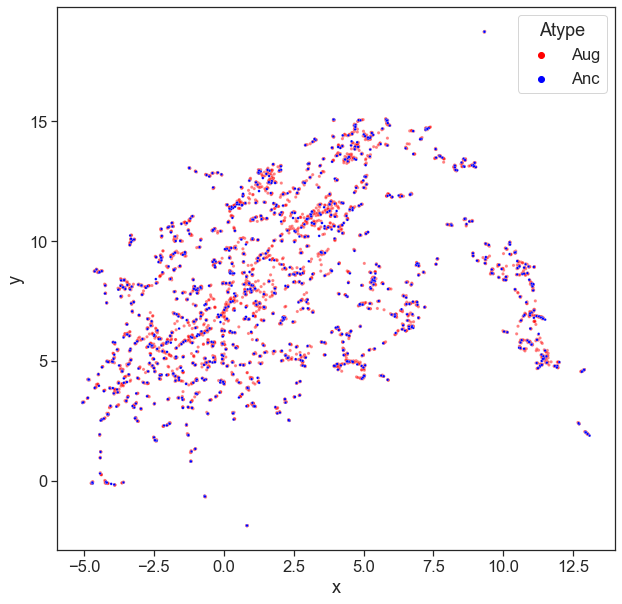

In [3]:
from eval_functions import *

import umap.umap_ as umap
import seaborn as sns 
import matplotlib.pylab as plt

# tag = '2022041804_04'
# tag = '2022041809_a04' 
tag = '2022041807_a03'


for eval_pair in [('train',False), ('01',False), ('01',True)]:
    
    which_test, test_ood = eval_pair
    
    which_train = '01'
    samp_size = 1000
    n_epochs = 30
    eval_bs = 6

    normed_latent = True
    use_cuda = True
    empty_cuda = True
    cuda_ids = [0,1,2,3]

    # Create tag.
    ood = 'ood' if test_ood else ''
    which = 'train' if which_test=='train' else 'test'
    which = 'ood' if test_ood else which
    tag_emb = '_'.join([x for x in [tag, f'{samp_size}n', which] if len(x)>0])
    print(tag_emb)

    # Get latent codes.
    df, latents = get_df_and_latents(tag, which_train, which_test, test_ood, samp_size, eval_bs, 
                                     n_epochs, normed_latent, use_cuda, empty_cuda, cuda_ids)
    n_ne = 32
    min_d = 0.1
    save_coords = True
    
    umapper = umap.UMAP(n_neighbors=n_ne, min_dist=min_d, n_components=2, metric='euclidean')
    embedding = umapper.fit_transform(latents)

    df['x'] = embedding[:, 0]
    df['y'] = embedding[:, 1]

    pt = str(min_d).split('.')[1]
    tag_coords = '_'.join([tag_emb, f'{n_ne}neigh', f'mindist0pt{pt}'])

    if save_coords:
        csv_out = f'results/umapped_dfs/{tag_coords}.csv'
        df.to_csv(csv_out,index=False)
        print(f"Saved smiles and coords to {csv_out}!")

    sns.set_theme(style='ticks',font_scale=1.5)
    plt.figure(figsize=(10,10))
    sns.scatterplot(data=df[df['Atype']=='Aug'], x='x', y='y', hue='Atype', 
                    alpha=0.5, s=10, palette={'Aug':'red'})
    sns.scatterplot(data=df[df['Atype']=='Anc'], x='x', y='y', hue='Atype', 
                    alpha=1., s=7, palette={'Anc':'blue'})
    png_out = f'results/umap_figs/{tag_coords}.png'
    plt.savefig(png_out, bbox_inches='tight')
    plt.show()